In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
import matplotlib.pyplot as plt

In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [6]:
dataset_path = "DATA/brain_tumor_dataset"

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [7]:
model = Sequential()

model.add(Conv2D(32,(3,3),
                 activation='relu',
                 input_shape=(224,224,3)))

model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),
                 activation='relu'))

model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),
                 activation='relu'))

model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128,
                activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1,
                activation='sigmoid'))

C:\Users\ADMIN\anaconda3\envs\brain_tumor\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5517 - loss: 0.8322 - val_accuracy: 0.6800 - val_loss: 0.6079
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 656ms/step - accuracy: 0.6552 - loss: 0.6350 - val_accuracy: 0.7000 - val_loss: 0.5962
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 683ms/step - accuracy: 0.7094 - loss: 0.5932 - val_accuracy: 0.6400 - val_loss: 0.6291
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 648ms/step - accuracy: 0.7537 - loss: 0.5474 - val_accuracy: 0.7200 - val_loss: 0.6208
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 623ms/step - accuracy: 0.7143 - loss: 0.5919 - val_accuracy: 0.7000 - val_loss: 0.6315
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 716ms/step - accuracy: 0.6946 - loss: 0.6509 - val_accuracy: 0.7600 - val_loss: 0.5954
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 673ms/step - accuracy: 0.7094 - loss: 0.5895 - val_accuracy: 0.6800 - val_loss: 0.6721
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 634ms/step - accuracy: 0.7537 - loss: 0.5775 - val_accuracy: 0.7200 - val_loss: 0

In [10]:
loss, accuracy = model.evaluate(val_data)

print("Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - accuracy: 0.7600 - loss: 0.4932
Accuracy: 0.7599999904632568


In [11]:
model.save("brain_tumor_model.h5")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step


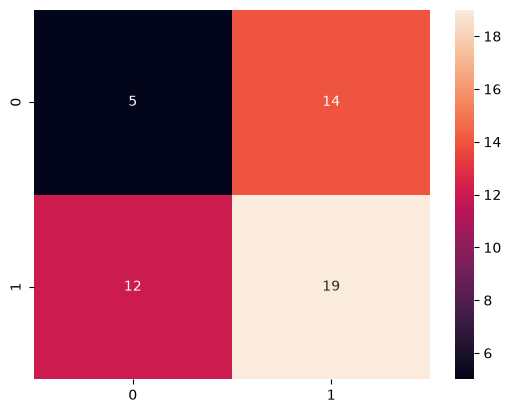

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(val_data)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(val_data.classes, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [13]:
from sklearn.metrics import classification_report

print(classification_report(
    val_data.classes,
    y_pred
))

              precision    recall  f1-score   support

           0       0.29      0.26      0.28        19
           1       0.58      0.61      0.59        31

    accuracy                           0.48        50
   macro avg       0.43      0.44      0.44        50
weighted avg       0.47      0.48      0.47        50



In [14]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [15]:
model = tf.keras.models.load_model("brain_tumor_model.h5")

In [16]:
for layer in model.layers:
    print(layer.name)

conv2d
max_pooling2d
conv2d_1
max_pooling2d_1
conv2d_2
max_pooling2d_2
flatten
dense
dropout
dense_1


In [17]:
last_conv_layer_name = "conv2d_2"

In [21]:
img_path = "DATA/test_mri.jpg"

img = tf.keras.preprocessing.image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

In [24]:
model.summary()

print(model.inputs)
print(model.outputs)

for layer in model.layers:
    print(layer.name)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,091 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer>]
[<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_118>]
conv2d
max_pooling2d
conv2d_1
max_pooling2d_1
conv2d_2
max_pooling2d_2
flatten
dense
dropout
dense_1


In [25]:
last_conv_layer_name = "conv2d_2"

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(last_conv_layer_name).output,
        model.outputs[0]
    ]
)

In [26]:
print(grad_model.output)

[<KerasTensor shape=(None, 52, 52, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_78>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_118>]


In [28]:
print(model.input_shape)
print(img_array.shape)

(None, 224, 224, 3)
(1, 224, 224, 3)


In [29]:
img = tf.keras.preprocessing.image.load_img(
    img_path,
    target_size=(224,224),
    color_mode='rgb'
)

In [35]:
dummy = tf.random.normal((1,224,224,3))
_ = model(dummy)

In [36]:
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer("conv2d_2").output,
        model.outputs[0]
    ]
)

In [37]:
print(model.inputs)
print(model.outputs)

[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer>]
[<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_118>]


In [40]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    tape.watch(conv_outputs)

    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)

print(grads)

None


In [41]:
conv_outputs, predictions = grad_model(img_array)

print("Conv shape:", conv_outputs.shape)
print("Predictions:", predictions.numpy())
print("Conv dtype:", conv_outputs.dtype)
print("Pred dtype:", predictions.dtype)

Conv shape: (1, 52, 52, 128)
Predictions: [[0.8274382]]
Conv dtype: <dtype: 'float32'>
Pred dtype: <dtype: 'float32'>


In [42]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    class_channel = tf.reduce_sum(predictions)

grads = tape.gradient(class_channel, conv_outputs)

print(grads is None)

True


In [44]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.21.0
Keras: 3.14.1


In [45]:
print(type(model))
print(model.built)

<class 'keras.src.models.sequential.Sequential'>
True


In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

new_model = Sequential([
    Input(shape=(224,224,3)),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu', name='last_conv'),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [48]:
new_model.set_weights(model.get_weights())

In [51]:
dummy = tf.random.normal((1,224,224,3))
_ = new_model(dummy)

In [52]:
dummy = tf.random.normal((1,224,224,3))
_ = new_model(dummy)

In [53]:
print(new_model.built)
print(new_model.inputs)
print(new_model.outputs)

True
[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_119>]
[<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_129>]


In [54]:
last_conv_layer = new_model.get_layer("last_conv")

grad_model = tf.keras.Model(
    inputs=new_model.inputs,
    outputs=[
        last_conv_layer.output,
        new_model.outputs[0]
    ]
)

In [55]:
conv_outputs, preds = grad_model(img_array)

print(conv_outputs.shape)
print(preds.shape)
print(preds.numpy())

(1, 52, 52, 128)
(1, 1)
[[0.8274382]]


C:\Users\ADMIN\anaconda3\envs\brain_tumor\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_119']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [56]:
with tf.GradientTape() as tape:

    conv_outputs, preds = grad_model(img_array)

    tape.watch(conv_outputs)

    loss = preds[:, 0]

grads = tape.gradient(loss, conv_outputs)

print(grads is None)
print(grads.shape)

False
(1, 52, 52, 128)


In [57]:
pooled_grads = tf.reduce_mean(
    grads,
    axis=(0, 1, 2)
)

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap, 0)

heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-10)

heatmap = heatmap.numpy()

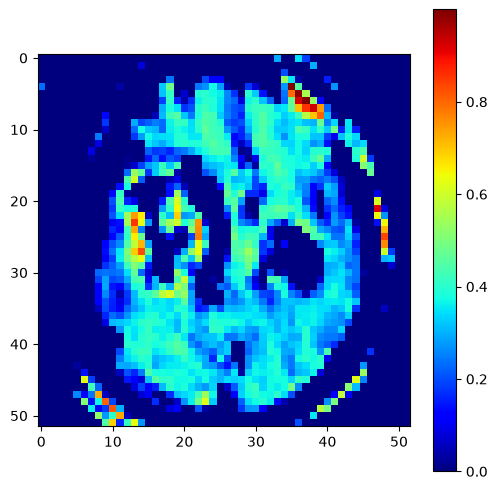

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(heatmap, cmap="jet")
plt.colorbar()
plt.show()

In [59]:
for layer in new_model.layers:
    print(layer.name)

conv2d_3
max_pooling2d_3
conv2d_4
max_pooling2d_4
last_conv
max_pooling2d_5
flatten_1
dense_2
dropout_1
dense_3


In [60]:
conv_outputs, preds = grad_model(img_array)

print(conv_outputs.shape)
print(preds.shape)
print(preds.numpy())

(1, 52, 52, 128)
(1, 1)
[[0.8274382]]


In [61]:
with tf.GradientTape() as tape:

    conv_outputs, preds = grad_model(img_array)

    tape.watch(conv_outputs)

    loss = preds[:, 0]

grads = tape.gradient(loss, conv_outputs)

print(grads.shape)

(1, 52, 52, 128)


In [62]:
pooled_grads = tf.reduce_mean(
    grads,
    axis=(0, 1, 2)
)

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(
    pooled_grads * conv_outputs,
    axis=-1
)

heatmap = tf.maximum(heatmap, 0)

heatmap /= (tf.reduce_max(heatmap) + 1e-8)

heatmap = heatmap.numpy()

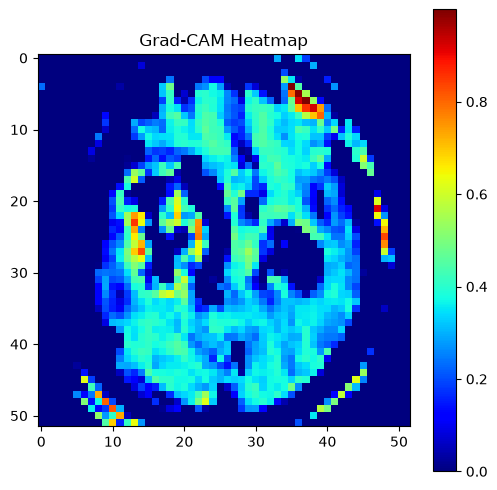

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(heatmap, cmap='jet')
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.show()

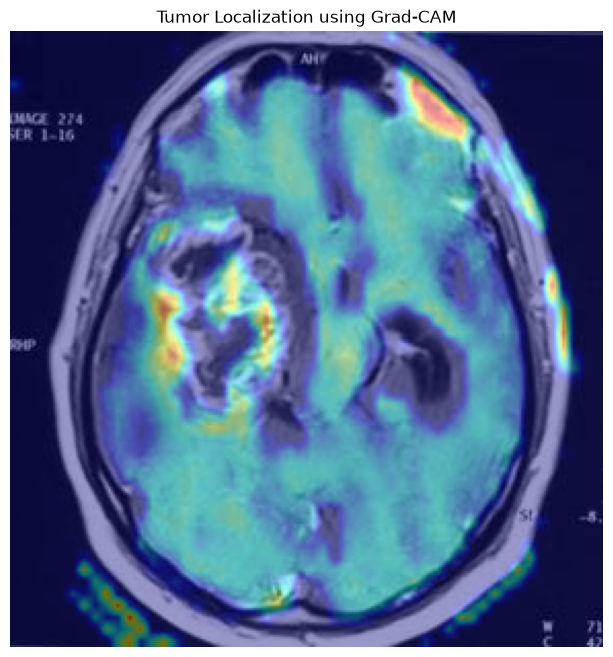

In [64]:
import cv2
import numpy as np

img = cv2.imread(img_path)

heatmap_resized = cv2.resize(
    heatmap,
    (img.shape[1], img.shape[0])
)

heatmap_resized = np.uint8(255 * heatmap_resized)

heatmap_color = cv2.applyColorMap(
    heatmap_resized,
    cv2.COLORMAP_JET
)

superimposed_img = cv2.addWeighted(
    img,
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(
    superimposed_img,
    cv2.COLOR_BGR2RGB
))
plt.axis("off")
plt.title("Tumor Localization using Grad-CAM")
plt.show()

In [65]:
cv2.imwrite(
    "tumor_gradcam_result.jpg",
    superimposed_img
)

True

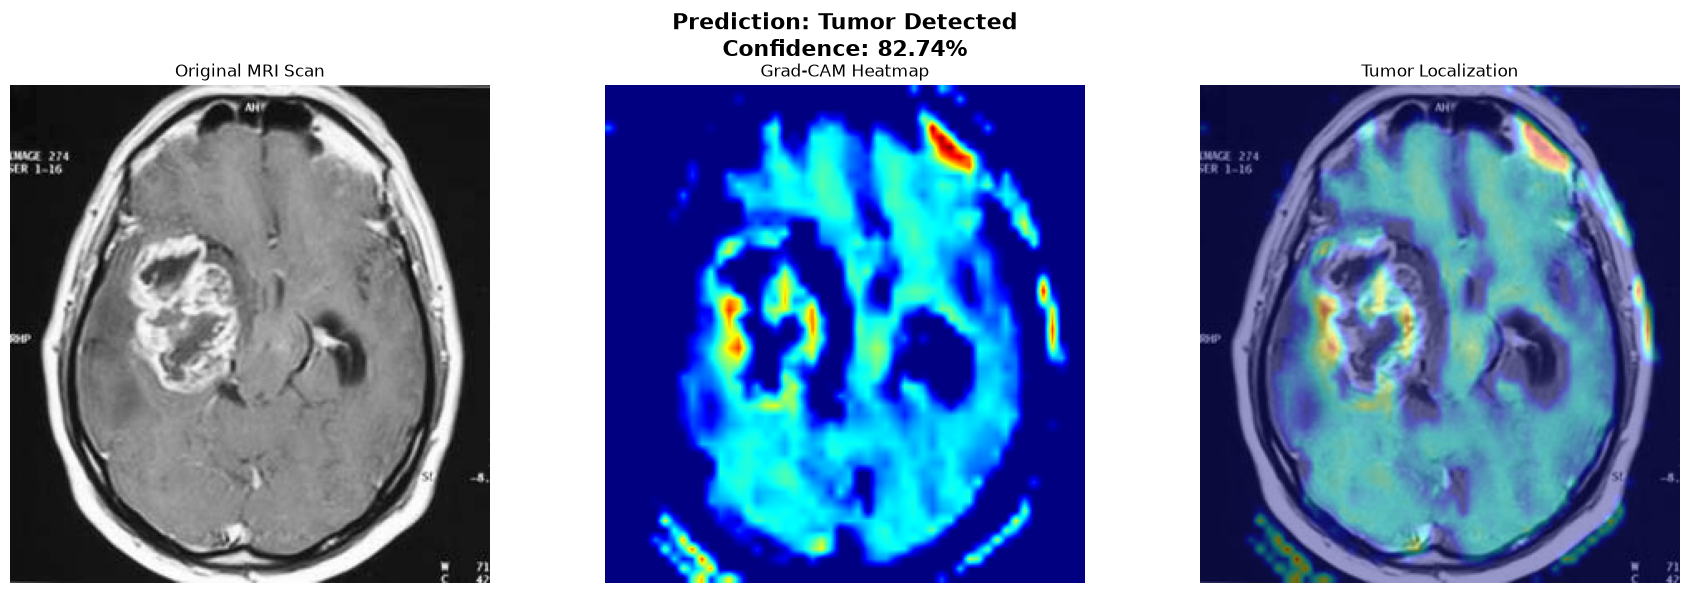

In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Original Image
original_img = cv2.imread(img_path)
original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Resize heatmap
heatmap_resized = cv2.resize(
    heatmap,
    (original_img.shape[1], original_img.shape[0])
)

# Convert heatmap to color
heatmap_uint8 = np.uint8(255 * heatmap_resized)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

heatmap_rgb = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Overlay
overlay_img = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_color,
    0.4,
    0
)

overlay_rgb = cv2.cvtColor(
    overlay_img,
    cv2.COLOR_BGR2RGB
)

# Prediction
confidence = float(preds[0][0]) * 100

if confidence >= 50:
    result = "Tumor Detected"
else:
    result = "No Tumor Detected"

# Display
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(original_rgb)
ax[0].set_title("Original MRI Scan")
ax[0].axis("off")

ax[1].imshow(heatmap_rgb)
ax[1].set_title("Grad-CAM Heatmap")
ax[1].axis("off")

ax[2].imshow(overlay_rgb)
ax[2].set_title("Tumor Localization")
ax[2].axis("off")

plt.suptitle(
    f"Prediction: {result}\nConfidence: {confidence:.2f}%",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [67]:
print("="*60)
print("BRAIN TUMOR DETECTION REPORT")
print("="*60)

print(f"Prediction           : {result}")
print(f"Tumor Probability    : {confidence:.2f}%")
print(f"Image Size           : {original_img.shape[1]} x {original_img.shape[0]}")
print(f"CNN Model            : Custom CNN")
print(f"Last Conv Layer      : conv2d_2")
print(f"Heatmap Resolution   : {heatmap.shape}")
print(f"Input Resolution     : 224 x 224")

if confidence > 80:
    risk = "HIGH"
elif confidence > 60:
    risk = "MEDIUM"
else:
    risk = "LOW"

print(f"Risk Level           : {risk}")

print("\nInterpretation:")
print("Red/Yellow regions indicate areas")
print("that contributed most to the CNN decision.")

print("="*60)

BRAIN TUMOR DETECTION REPORT
Prediction           : Tumor Detected
Tumor Probability    : 82.74%
Image Size           : 289 x 300
CNN Model            : Custom CNN
Last Conv Layer      : conv2d_2
Heatmap Resolution   : (52, 52)
Input Resolution     : 224 x 224
Risk Level           : HIGH

Interpretation:
Red/Yellow regions indicate areas
that contributed most to the CNN decision.


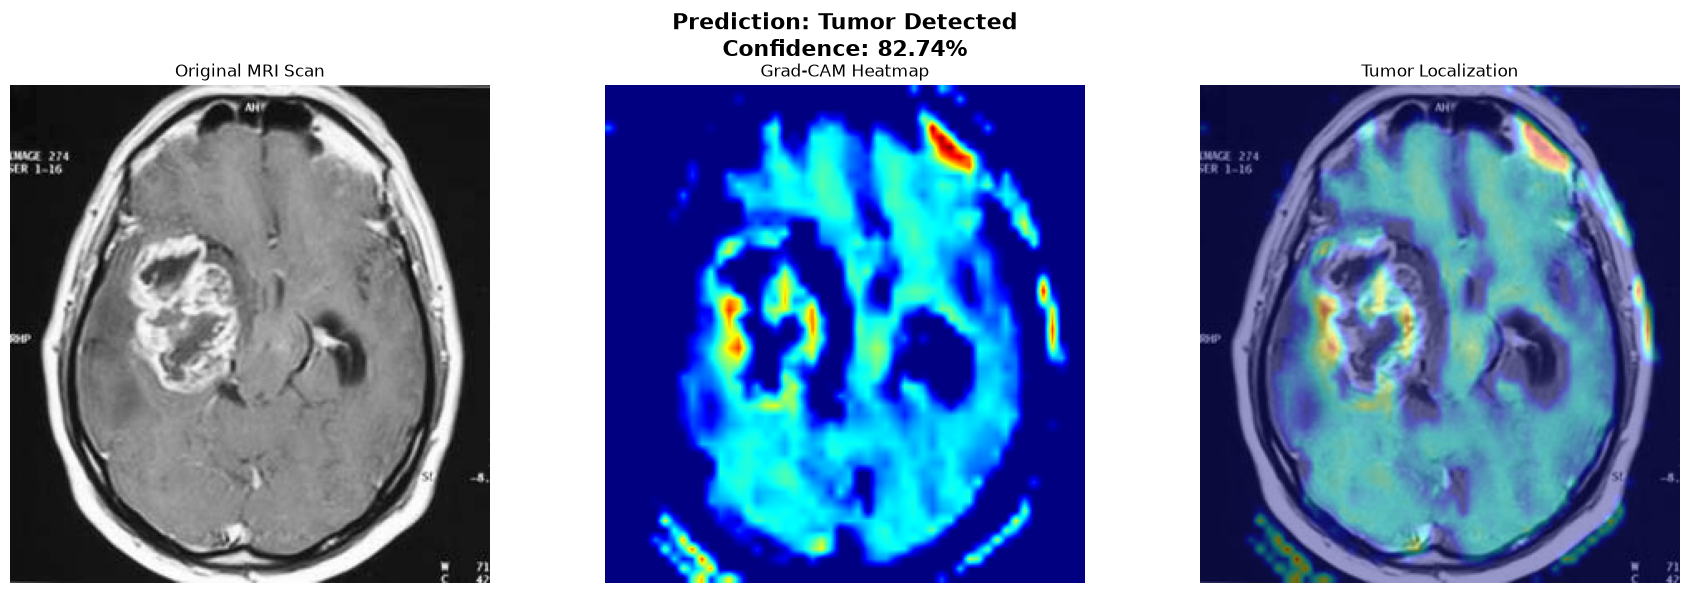

BRAIN TUMOR DETECTION REPORT
Prediction           : Tumor Detected
Tumor Probability    : 82.74%
Image Size           : 289 x 300
CNN Model            : Custom CNN
Last Conv Layer      : conv2d_2
Heatmap Resolution   : (52, 52)
Input Resolution     : 224 x 224
Risk Level           : HIGH

Interpretation:
Red/Yellow regions indicate areas
that contributed most to the CNN decision.


In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Original Image
original_img = cv2.imread(img_path)
original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Resize heatmap
heatmap_resized = cv2.resize(
    heatmap,
    (original_img.shape[1], original_img.shape[0])
)

# Convert heatmap to color
heatmap_uint8 = np.uint8(255 * heatmap_resized)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

heatmap_rgb = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Overlay
overlay_img = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_color,
    0.4,
    0
)

overlay_rgb = cv2.cvtColor(
    overlay_img,
    cv2.COLOR_BGR2RGB
)

# Prediction
confidence = float(preds[0][0]) * 100

if confidence >= 50:
    result = "Tumor Detected"
else:
    result = "No Tumor Detected"

# Display
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(original_rgb)
ax[0].set_title("Original MRI Scan")
ax[0].axis("off")

ax[1].imshow(heatmap_rgb)
ax[1].set_title("Grad-CAM Heatmap")
ax[1].axis("off")

ax[2].imshow(overlay_rgb)
ax[2].set_title("Tumor Localization")
ax[2].axis("off")

plt.suptitle(
    f"Prediction: {result}\nConfidence: {confidence:.2f}%",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print("="*60)
print("BRAIN TUMOR DETECTION REPORT")
print("="*60)

print(f"Prediction           : {result}")
print(f"Tumor Probability    : {confidence:.2f}%")
print(f"Image Size           : {original_img.shape[1]} x {original_img.shape[0]}")
print(f"CNN Model            : Custom CNN")
print(f"Last Conv Layer      : conv2d_2")
print(f"Heatmap Resolution   : {heatmap.shape}")
print(f"Input Resolution     : 224 x 224")

if confidence > 80:
    risk = "HIGH"
elif confidence > 60:
    risk = "MEDIUM"
else:
    risk = "LOW"

print(f"Risk Level           : {risk}")

print("\nInterpretation:")
print("Red/Yellow regions indicate areas")
print("that contributed most to the CNN decision.")

print("="*60)